# Custom Middleware
**Build custom middleware by implementing hooks that run at specific points in the agent execution flow**

**Why Custm Middleware**

* `HumanInTheLoopMiddleware` handles approval for any tool. `PIIMiddleware` handles any of five PII types. 
* Sometime agent needs rules that not built in: 
  * no customer books more than 2 movies in one session
  * flag it if the bot ever mentions a rival cinema chain by name
  * log every cancellation in our own specific audit format.

Nothing generic can anticipate rules that are yours alone.

## Hooks

<img src="../../assets/custom_middleware.png" width="900" height="400">

Middleware provides two styles of hooks to intercept agent execution

1. **Node-style hooks**: Run sequentially at specific execution points. Use for logging, validation, and state updates.

| Hook           | When it runs                                |
| -------------- | ------------------------------------------- |
| `before_agent` | Before agent starts (once per invocation)   |
| `before_model` | Before each model call                      |
| `after_model`  | After each model response                   |
| `after_agent`  | After agent completes (once per invocation) |

**Return values:**
* `None` - Continue normal execution
* `dict` - Update state with returned values
* `{"jump_to": "end"}` - Exit early (requires `can_jump_to` config)

2. **Wrap-style hooks**: Run around each call, giving you control over execution.
* Intercept execution and control when the handler is called. You decide:
  * Call handler zero times (short-circuit)
  * Call handler once (normal flow)
  * Call handler multiple times (retry logic)

| Hook              | When it runs           |
| ----------------- | ---------------------- |
| `wrap_model_call` | Around each model call |
| `wrap_tool_call`  | Around each tool call  |

---

<img src="../../assets/middlewares_graph.png" width="400" height="500">


In [3]:
# --- Core LangChain ---
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent, AgentState
from langchain_core.tools import tool
from typing_extensions import NotRequired

# --- Middleware building blocks -- every one used in this notebook ---
from langchain.agents.middleware import (
    AgentMiddleware,
    before_model,
    after_model,
    before_agent,
    after_agent,
    wrap_model_call,
    ModelRequest,
    ModelResponse,
    ExtendedModelResponse,
    hook_config
)
from langgraph.types import Command
from langchain.messages import HumanMessage, AIMessage
from typing import Any, Callable
from typing_extensions import NotRequired
from langgraph.runtime import Runtime

from rich import print
import sys
sys.path.append('..')
from utils.helper import pretty_print_agent_output, print_messages

#### Define Tools
* Define four tools for checking showtimes, booking seats, cancelling bookings, and retrieving the refund policy. 
* The `tools` list makes these functions available to later agents.

In [2]:
@tool
def check_showtimes(movie_title: str) -> str:
    """Check available showtimes for a movie at the cinema."""
    fake_showtimes = {
        "interstellar": "7:00 PM and 10:15 PM",
        "dune part two": "9:30 PM only",
        "oppenheimer": "Sold out for tonight",
    }
    return fake_showtimes.get(movie_title.lower(), "No showtimes found for that title.")

@tool
def book_seats(movie_title: str, seat_count: int) -> str:
    """Book seats for a movie. Irreversible once confirmed."""
    return f"Booked {seat_count} seat(s) for {movie_title}."

@tool
def cancel_booking(booking_id: str) -> str:
    """Cancel an existing booking. Irreversible."""
    return f"Booking {booking_id} cancelled."

@tool
def get_refund_policy() -> str:
    """Get the cinema's refund policy -- exact wording, not to be paraphrased."""
    return "Refunds available up to 2 hours before showtime. No refunds after that."

tools = [check_showtimes, book_seats, cancel_booking, get_refund_policy]

#### Define node-style hooks
* Define hooks that log agent/model lifecycle events, increment `model_call_count` before each model call, and simulate connecting to and disconnecting from a database. 
* Hooks returning `None` leave the state unchanged.

**Extend agent state**

It creates `TrackingState`, adding an optional `model_call_count` field to the standard agent state so middleware can track how many model calls occur.

In [31]:
class TrackingState(AgentState):
    model_call_count: NotRequired[int]

@before_model(state_schema=TrackingState)
def log_before_model(state: TrackingState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the model.
    Arguments:
        state: The current state of the agent that have been accumulated so far.
        runtime: The runtime environment, that contains information about the execution context.
    """
    print(f"[LOG] before_model: About to call model with {len(state['messages'])} messages so far")
    return {"model_call_count": state.get("model_call_count", 0) + 1} # return a dict to update the state

@before_agent(state_schema=TrackingState)
def connecting_to_db(state: TrackingState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the model.
    Arguments:
        state: The current state of the agent that have been accumulated so far.
        runtime: The runtime environment, that contains information about the execution context.
    """
    print(f"before_agent: I have connected to DB: {state.get('model_call_count', 0)}")
    return None # return None to not update the state

@after_agent(state_schema=TrackingState)
def disconnecting_to_db(state: TrackingState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the model.
    Arguments:
        state: The current state of the agent that have been accumulated so far.
        runtime: The runtime environment, that contains information about the execution context.
    """
    print(f"after_agent: I have disconnected to DB: {state.get('model_call_count', 0)}")
    return None # return None to not update the state

@before_agent(state_schema=TrackingState)
def log_before_agent(state: TrackingState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the agent.
    Arguments:
        state: The current state of the agent that has been accumulated so far.
        runtime: The runtime environment, that contains information about the execution context.
    """
    print('before_agent: ',type(state), type(runtime))
    print(f"[LOG] before_agent Hello World: {state.get('model_call_count', 0)}")
    return None # return None to not update the state

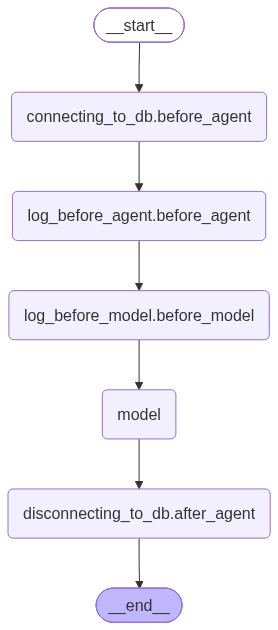

In [32]:
logged_agent = create_agent(model='openai:gpt-5-nano', tools=[], middleware=[log_before_model, connecting_to_db, disconnecting_to_db, log_before_agent])
logged_agent

**Invoke the logging agent**

* Sends a greeting to `logged_agent`. 
* The output is an agent result containing the conversation messages; the console also shows `before_agent`, `before_model`, and `after_agent` logs, with `model_call_count` incremented to 1.

In [34]:
result = logged_agent.invoke({"messages": [("user", "Hi, How are you?")]})

before_agent: I have connected to DB: 0

before_agent:  <class 'dict'> <class 'langgraph.runtime.Runtime'>

[LOG] before_agent Hello World: 0

[LOG] before_model: About to call model with 1 messages so far

after_agent: I have disconnected to DB: 1

#### 2. Define Wrap-style hooks
* Intercept execution and control when the handler is called.
* Use for retries, caching, and transformation.
* You decide if the handler is called zero times (short-circuit), once (normal flow), or multiple times (retry logic).
* Return a `ExtendedModelResponse` with a `Command` from `wrap_model_call` to inject state updates from the model call layer

**Available hooks:**
1. `wrap_model_call` - Around each model call
2. `wrap_tool_call` - Around each tool call

**Define usage-tracking middleware**

* Adds `last_model_call_tokens` to the state and wraps each model call. 
* It reads token usage from the response metadata, prints it, and returns an `ExtendedModelResponse` containing a `Command` that updates the state.

In [35]:
class UsageTrackingState(AgentState):
    """Agent state with token usage tracking."""
    last_model_call_tokens: NotRequired[int]

@wrap_model_call(state_schema=UsageTrackingState)
def track_usage(request: ModelRequest,handler: Callable[[ModelRequest], ModelResponse]) -> ExtendedModelResponse:
    response: ModelResponse = handler(request)
    response_metadata = response.result[0].response_metadata
    token_usage = response_metadata.get("token_usage", {})
    print("Token usage for this model call:", token_usage)
    return ExtendedModelResponse(
        model_response=response,
        command=Command(update={"last_model_call_tokens": token_usage.get("total_tokens", 0)}),
    )

**Build the usage-tracking agent**
* Creates an agent with `track_usage` middleware and no tools. 
* The agent will record token usage for every model call.

In [36]:
agent  = create_agent(model='openai:gpt-5-nano', tools=[], middleware=[track_usage])

**Invoke the usage-tracking agent**

* Invoke the agent, It returns the conversation in `response` and prints a token-usage dictionary such as `total_tokens`
* Exact counts and poem text depend on the model response.

In [37]:
response = agent.invoke({"messages": [("user", "Write a short 3-word poem.")]})

Token usage for this model call:
{
    'completion_tokens': 591,
    'prompt_tokens': 14,
    'total_tokens': 605,
    'completion_tokens_details': {
        'accepted_prediction_tokens': 0,
        'audio_tokens': 0,
        'reasoning_tokens': 576,
        'rejected_prediction_tokens': 0
    },
    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
}

#### Dynamic Tool Selection
**Define VIP-based tool gating**
* Adds VIP membership to the agent state, defines a VIP lounge booking tool, and wraps model calls to remove that tool when `is_vip_member` is false.
* It prints the membership flag and the tools exposed for the current request.

In [55]:

class UserState(AgentState):
    """Agent state with VIP membership tracking."""
    is_vip_member: NotRequired[bool]

@tool
def book_vip_lounge(movie_title: str) -> str:
    """Book a VIP lounge seat with premium service. VIP members only."""
    return f"VIP lounge seat booked for {movie_title}."

@wrap_model_call(state_schema=UserState)
def gate_vip_tools(request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse:
    """Only expose book_vip_lounge to VIP members.
    Arguments:
        request: The model request, containing messages and other context.
        handler: The next handler in the middleware chain, which will call the model."""
    is_vip = request.state['is_vip_member']
    print("Is VIP Member: ", is_vip)
    if not is_vip:
        allowed = [t for t in request.tools if t.name != "book_vip_lounge"]
        request = request.override(tools=allowed)
    print("Loaded Tools: ", [t.name for t in request.tools])
    return handler(request)


**Build the gated agent**

* Create `gated_agent` with the cinema tools, the VIP lounge tool, and the `gate_vip_tools` middleware.
* Tool availability is decided for each invocation from the request state.

In [56]:
gated_agent = create_agent(model="openai:gpt-5-nano", tools=[*tools, book_vip_lounge], middleware=[gate_vip_tools])

**Invoke the gated agent as a VIP member**

* This invocation sets `is_vip_member` to `True`.
* The middleware keeps `book_vip_lounge` Tool available, so the model can call it and confirm a VIP lounge booking.

In [58]:
result = gated_agent.invoke({"messages": [("user", "Book me a VIP lounge seat for Dune")], "is_vip_member": True})
print(result["messages"][-1].content)

Is VIP Member:  True

Loaded Tools: 
['check_showtimes', 'book_seats', 'cancel_booking', 'get_refund_policy', 'book_vip_lounge']

VIP lounge bookings are for VIP members only. Are you a VIP member? If yes, please tell me the showtime (date and 
time) you want for Dune and I’ll book a VIP lounge seat for you. 

If you’re not a VIP, I can:
- check available standard seating options for Dune, or
- help you with VIP membership options to enable future VIP lounge bookings.

**Invoke the gated agent as a non-VIP member**

* This invocation sets `is_vip_member` to `False`.
* The middleware removes `book_vip_lounge` Tool before the model call, so the agent cannot use that tool.

In [59]:
result = gated_agent.invoke({"messages": [("user", "Book me a VIP lounge seat for Dune")], "is_vip_member": False})
print(result["messages"][-1].content)

Is VIP Member:  False

Loaded Tools: 
['check_showtimes', 'book_seats', 'cancel_booking', 'get_refund_policy']

I can help with that. A couple of details I need before I can book:

- Which cinema/location do you want to use (if you have a preferred one)?
- Date/time or should I book the next available Dune showing?
- How many seats? (I’ll book 1 as you requested.)
- Confirm you want VIP lounge seating specifically (premium seating), not standard.

Note: Booking is irreversible, and the system may require confirming the exact showtime. I can also fetch the exact
refund policy for you before you confirm.

If you’d like, I can start by checking showtimes for Dune now and list the next options with VIP lounge 
availability. Just say “check showtimes” and I’ll proceed.

#### Dynamic Model Selection
**Initialize two models**
* Initialize an advanced model and a less expensive basic model. 
* The dynamic middleware will choose between them based on conversation length.

In [61]:
advanced_model = init_chat_model("openai:gpt-5-mini")
basic_model = init_chat_model("openai:gpt-5-nano")

**Define dynamic model selection**

* This wrap hook counts the current messages and selects `basic_model` for short conversations or `advanced_model` when there are more than two messages.
* It then forwards the request with the selected model.

In [77]:
@wrap_model_call
def dynamic_model_selection(request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse:
    """Use a cheap model for short conversations, a capable one once it gets complex.
    Arguments:
        request: The model request, containing agent state and runtime context that have information about the current conversation.
        handler: The next handler in the middleware chain, which will call the model."""
    message_count = len(request.state["messages"])
    chosen_model = advanced_model if message_count > 2 else basic_model
    return handler(request.override(model=chosen_model))

**Run the cost-aware agent**

* Creates an agent with the dynamic model-selection middleware and cinema tools, then asks about showtimes and seat booking.
* The result contains the conversation and tool calls.
* The selected model is initially the basic model because the request starts with one message.

In [78]:
cost_aware_agent = create_agent(model=basic_model, tools=tools, middleware=[dynamic_model_selection])
result = cost_aware_agent.invoke({"messages": [HumanMessage(content="can you check show times for interstellar, also please book me 2 seats for the 7:00 PM show?")]})

**Verify Model Used**
* Scans the returned messages for `AIMessage` objects and prints each response's `model_name`. 
* It lets you verify which model handled each model call; the exact names depend on the provider metadata.

In [89]:
for res in result['messages']:
    if isinstance(res, AIMessage):
        print(res.response_metadata['model_name'])

gpt-5-nano-2025-08-07

gpt-5-mini-2025-08-07

gpt-5-mini-2025-08-07

## Execution order
When using multiple middleware, understand how they execute:
```python
    agent = create_agent(
        model="gpt-5.5",
        middleware=[middleware1, middleware2, middleware3],
        tools=[...],
)
```

**Before hooks run in order:**
1. middleware1.before_agent()
2. middleware2.before_agent()
3. middleware3.before_agent()

**Agent loop starts**

4. middleware1.before_model()
5. middleware2.before_model()
6. middleware3.before_model()

**Wrap hooks nest like function calls:**

7. middleware1.wrap_model_call() → middleware2.wrap_model_call() → middleware3.wrap_model_call() → model

**After hooks run in reverse order:**

8. middleware3.after_model()
9. middleware2.after_model()
10. middleware1.after_model()

**Agent loop ends**
11. middleware3.after_agent()
12. middleware2.after_agent()
13. middleware1.after_agent()

**Key rules**
* **before_* hooks**: First to last - FIFO (1 → 2 → 3)
* **after_* hooks**: Last to first (reverse) - LIFO (3 → 2 → 1).
* **wrap_* hooks**: Nested (first middleware wraps all others) - Nested (1 → 2 → 3 → model → 3 → 2 → 1)

## Class-based middleware
* More powerful for complex middleware with multiple hooks or configuration. 
* Use classes when you need to define both sync and async implementations for the same hook, or when you want to combine multiple hooks in a single middleware.
* An `AgentMiddleware` subclass can declare three class attributes that the agent factory picks up at compile time:
    * `state_schema` - extend the agent state with custom fields.
    * `tools` - register additional tools that ship with the middleware (e.g., write_todos on the to-do list middleware).
    * `transformers` - register scope-aware stream transformer factories.

**When to use classes**
* Defining both sync and async implementations for the same hook
* Multiple hooks needed in a single middleware
* Complex configuration required (e.g., configurable thresholds, custom models)
* Reuse across projects.

#### Below is example Class based cutom Middleware that Logs the execution flow at each intercept of Agentic Loop.
* Define `LoggingMiddleware`, an `AgentMiddleware` subclass implementing agent, model, and tool lifecycle hooks. 
* Each hook logs before and after events

In [93]:
class LoggingMiddleware(AgentMiddleware):

    def before_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print(f"before_agent: -> About to call agent with {len(state['messages'])} messages")
        return None

    def after_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print(f"after_agent: -> Agent finished processing with {len(state['messages'])} messages")
        return None

    def before_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print(f"before_model: -> About to call model with {len(state['messages'])} messages")
        return None

    def after_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print(f"after_model: -> Model returned: {state['messages'][-1].content}")
        return None

    def wrap_tool_call(self, request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse:
        print(f"wrap_tool_call: -> About to call tool with {len(request.state['messages'])} messages")
        response = handler(request) # This is where the tool is actually called, and the response is captured
        print(f"wrap_tool_call: -> Tool returned: {response}")
        return response
    
    def wrap_model_call(self, request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse:
        print(f"wrap_model_call: -> About to call model with {len(request.state['messages'])} messages")
        response = handler(request) # This is where the model is actually called, and the response is captured
        print(f"wrap_model_call: -> Model returned: {response.result[0].content}")
        return response

agent = create_agent(
    model="openai:gpt-5-nano",
    middleware=[LoggingMiddleware()],
    tools=[check_showtimes, book_seats, cancel_booking, get_refund_policy, book_vip_lounge],
)

**Invoke the class-based middleware agent**
* Invoke agent and ask for Interstellar showtimes. 
* The result includes the assistant response and a tool call to `check_showtimes`
* Console output logs the `before_agent`, `before_model`, `wrap_model_call`, `wrap_tool_call`, `after_model`, and `after_agent` stages that occur in sequence.

In [94]:
result = agent.invoke({"messages": [HumanMessage(content="can you check show times for interstellar?")]})

before_agent: -> About to call agent with 1 messages

before_model: -> About to call model with 1 messages

wrap_model_call: -> About to call model with 1 messages

wrap_model_call: -> Model returned:

after_model: -> Model returned:

...

before_model: -> About to call model with 3 messages

wrap_model_call: -> About to call model with 3 messages

wrap_model_call: -> Model returned: Interstellar showtimes available: 7:00 PM and 10:15 PM.

Which showtime would you like to book, and how many seats?

after_model: -> Model returned: Interstellar showtimes available: 7:00 PM and 10:15 PM.

Which showtime would you like to book, and how many seats?

after_agent: -> Agent finished processing with 4 messages

## Agent Jumps
Exit early from middleware by returning `{"jump_to": "target"}`.

**Jump targets**

* "end" - Jump to end of agent execution
* "tools" - Jump to tools node
* "model" - Jump to model node

Requires `can_jump_to` config on the hook.

**Content Blocker Middleware**
* This middleware blocks unsafe responses by checking the model output after generation.
* If any blocked word appears, it:
    * creates a safe replacement message
    * `@hook_config(can_jump_to=["end"])` allows the middleware to exit execution early

Example behavior:
* If the model says something containing “cricket”
* The middleware replaces it with:
    * "There is some content that is not allowed to be discussed."
* The agent then exits without continuing

In [ ]:
class ContentBlockerMiddleware(AgentMiddleware):
    """Block any response containing words in the blocked_words list."""

    def __init__(self, blocked_words: list[str]):
        super().__init__()
        self.blocked_words = [w.lower() for w in blocked_words]
    
    @hook_config(can_jump_to=["end"])
    def after_model(self, state: AgentState,  runtime: Runtime) -> dict[str, Any] | None:        
        last_message = str(state["messages"][-1].content).lower()
        if any(word in last_message for word in self.blocked_words):
            return {
                "messages": [AIMessage("There is some content that is not allowed to be discussed.")],
                "jump_to": "end"
            }
        return None

In [6]:
agent = create_agent(
    model="openai:gpt-5-nano",
    middleware=[ContentBlockerMiddleware(blocked_words=["fifa", 'cricket', 'soccer', 'baseball'])],
)

In [7]:
result = agent.invoke({
    "messages": [HumanMessage(content="When was the first cricket match was played?")]
})

In [8]:
print(result['messages'][-1].content)

There is some content that is not allowed to be discussed.